

## Problem Statement
This project analyzes retail transaction data to understand key drivers of sales across product categories and customer segments, and builds a machine learning model to predict order-level sales using a structured preprocessing pipeline.

In [75]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

In [76]:
df = pd.read_csv('/Users/adronallen/Downloads/train.csv')
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

# Minimal Data Cleaning

In [77]:
df.isnull().sum()
df.dropna(subset=['Sales'], inplace=True)

# EDA

In [78]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

In [79]:
df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

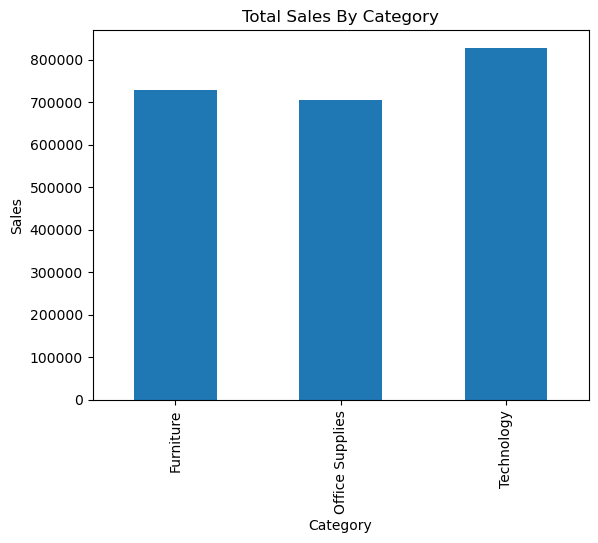

In [80]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title('Total Sales By Category')
plt.ylabel('Sales')
plt.show

## Defining Target & Feature Engineering 

In [81]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')

df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Day'] = df['Order Date'].dt.day
df['Order_DayOfWeek'] = df['Order Date'].dt.dayofweek

df.drop('Order Date', axis=1, inplace=True)

In [82]:
y = df['Sales']
X = df.drop(['Sales'], axis=1)

In [83]:
X_train, X_valid, y_train, y_valid = train_test_split(X,y, random_state=1)

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

## Preprocessing

In [84]:
numerical_transformer = SimpleImputer(strategy='median')

categorical_transformer = Pipeline(steps =[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]                             
)

In [85]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer,categorical_cols)
    ]
)

In [86]:
model = RandomForestRegressor(random_state=1)

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

**Predictions**

In [89]:
clf.fit(X_train,y_train)
preds = clf.predict(X_valid)
print(preds)

[110.09588 233.13866 135.58888 ...  16.32288   9.6613   24.13102]


In [88]:
mean_absolute_error(y_valid,preds)

136.8585632310204

## Insights

1. Exploratory Data Analysis

Technology was the highest-grossing category, followed by Furniture and Office Supplies — each exceeding $700K in total sales, confirming a high-volume retail environment with meaningful cross-category revenue concentration.

2. Baseline Model Performance

The baseline Random Forest Regressor achieved an MAE of 136.86, capturing broad transaction variance from low-value orders (~$10) to high-value ones (~$233). The error reflects the model's difficulty distinguishing lower-value items, pointing to a skewed target distribution as the primary bottleneck.

3. Next Steps

Log-transform the target variable to reduce the influence of high-value outliers and improve precision on lower-value transactions
Strengthen categorical encoding by leveraging Category and Sub-Category more aggressively to help the model separate structurally different price points
Add RMSE alongside MAE to better penalize large prediction errors and get a fuller picture of model variance